In [ ]:
!pip install awswrangler



In [ ]:
import awswrangler as wr

import boto3
glue = boto3.client("glue", region_name='us-east-1')
databases = [db["Name"] for db in glue.get_databases()["DatabaseList"]]
print(databases)

def list_glue_tables(database_name: str):
    tables = []
    paginator = glue.get_paginator("get_tables")

    for page in paginator.paginate(DatabaseName=database_name):
        for table in page["TableList"]:
            tables.append({
                "name": table["Name"],
                "location": table.get("StorageDescriptor", {}).get("Location"),
                "columns": [c["Name"] for c in table.get("StorageDescriptor", {}).get("Columns", [])],
            })
    return tables

# Example: SageMaker Feature Store database
tables = list_glue_tables("fraud_db")

for t in tables:
    print(t["name"], "->", t["location"])


df = wr.athena.read_sql_query(sql="select * from AwsDataCatalog.fraud_db.creditcard", database="fraud_db")
df.head()


['default', 'dsoaws', 'fraud_db', 'homework_datalake_db', 'sagemaker_featurestore']
creditcard -> s3://fraud-risk-datalake-team5/raw
raw -> s3://fraud-risk-datalake-team5/raw/
temp_table_7c0ab5976b404efda82720ae19c55c04 -> s3://aws-athena-query-results-890037892001-us-east-1/temp_table_7c0ab5976b404efda82720ae19c55c04


,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
0,149290.0,-0.034383,0.797535,-2.183072,-2.167611,3.606664,2.753527,1.077644,0.608669,-0.554141,...,0.244460,0.798019,-0.207894,0.754950,-0.272556,0.109015,0.414179,0.262318,3.85,0
1,149290.0,1.936389,0.386548,-2.578881,2.710820,3.210552,3.966910,-0.007463,0.820053,-1.295594,...,-0.021224,-0.091871,0.132601,0.680938,0.256628,0.040781,-0.043626,-0.066132,9.44,0
2,149291.0,-0.378291,1.348351,-0.958058,-0.170333,-0.181683,-1.317496,0.167440,0.416686,-0.274481,...,0.472062,1.191883,0.003311,0.101168,-0.233621,-0.177273,-0.464422,-0.144166,1.00,0
3,149291.0,-0.365847,1.394585,-0.883129,-0.130852,0.474152,-1.344975,0.741068,0.066038,-0.266581,...,0.332433,1.126089,-0.071362,-0.049192,-0.269751,-0.147150,0.153847,0.116588,14.99,0
4,149291.0,-1.074139,-1.002655,3.033710,-2.738858,-1.603762,0.367193,-1.491464,0.488061,-0.908751,...,-0.015778,0.655567,-0.453662,0.088775,0.433250,-0.001219,0.265198,0.096608,14.47,0


In [ ]:

df.columns.tolist()


['time',
 'v1',
 'v2',
 'v3',
 'v4',
 'v5',
 'v6',
 'v7',
 'v8',
 'v9',
 'v10',
 'v11',
 'v12',
 'v13',
 'v14',
 'v15',
 'v16',
 'v17',
 'v18',
 'v19',
 'v20',
 'v21',
 'v22',
 'v23',
 'v24',
 'v25',
 'v26',
 'v27',
 'v28',
 'amount',
 'class']

In [ ]:
df.shape
df.info()
df.describe()
df['class'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   time    284807 non-null  float64
 1   v1      284807 non-null  float64
 2   v2      284807 non-null  float64
 3   v3      284807 non-null  float64
 4   v4      284807 non-null  float64
 5   v5      284807 non-null  float64
 6   v6      284807 non-null  float64
 7   v7      284807 non-null  float64
 8   v8      284807 non-null  float64
 9   v9      284807 non-null  float64
 10  v10     284807 non-null  float64
 11  v11     284807 non-null  float64
 12  v12     284807 non-null  float64
 13  v13     284807 non-null  float64
 14  v14     284807 non-null  float64
 15  v15     284807 non-null  float64
 16  v16     284807 non-null  float64
 17  v17     284807 non-null  float64
 18  v18     284807 non-null  float64
 19  v19     284807 non-null  float64
 20  v20     284807 non-null  float64
 21  v21     28

class
0    284315
1       492
Name: count, dtype: Int64

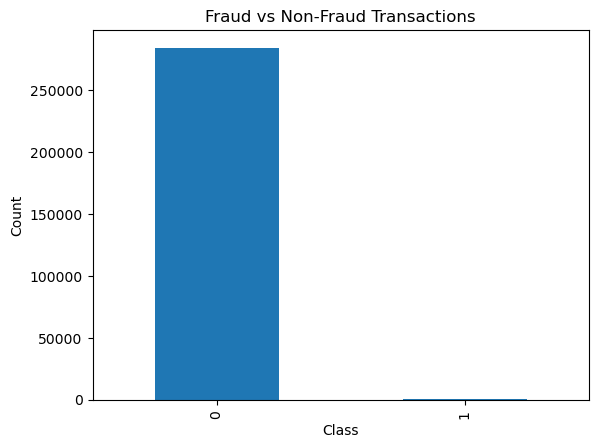

In [ ]:
import matplotlib.pyplot as plt

df["class"].value_counts().plot(kind='bar')
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Dataset

[Credit Card Fraud Detection (Kaggle)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — 284,807 European cardholder transactions (September 2013), **492 frauds (0.172%)**.

| Column | Description |
|--------|-------------|
| `Time` | Seconds since first transaction |
| `V1`–`V28` | PCA-transformed features |
| `Amount` | Transaction amount |
| `Class` | `1` = fraud, `0` = legitimate |

> **Evaluation note:** For this imbalanced dataset, use **AUPRC** (Area Under Precision-Recall Curve), not accuracy.

## Feature Groups

| Feature Group | Primary Key | Purpose |
|---------------|-------------|---------|
| `creditcard-transaction` | `transaction_id` | Per-transaction features for real-time inference |
| `hourly-fraud-risk` | `hour` | Aggregated temporal risk profile (0–23) |

**Kernel:** `Python 3 (Data Science)` on SageMaker Studio/Lab  
**IAM:** `AmazonSageMakerFullAccess`, `AmazonS3FullAccess`


In [ ]:
!pip3 install -U sagemaker

In [ ]:
df_fe = df.copy()

print(df_fe.shape)


(284807, 31)


In [ ]:
df_fe["hour"] = (df_fe["time"] // 3600) % 24

df_fe[["time", "hour"]].head()

,time,hour
0,149290.0,17.0
1,149290.0,17.0
2,149291.0,17.0
3,149291.0,17.0
4,149291.0,17.0


In [ ]:
import numpy as np

df_fe["log_amount"] = np.log1p(df_fe["amount"])

df_fe[["amount", "log_amount"]].head()

,amount,log_amount
0,3.85,1.578979
1,9.44,2.345645
2,1.00,0.693147
3,14.99,2.771964
4,14.47,2.738903


In [ ]:
amount_mean = df_fe["amount"].mean()
amount_std = df_fe["amount"].std()

df_fe["amount_zscore"] = (
    (df_fe["amount"] - amount_mean)
    / amount_std
)

df_fe[["amount", "amount_zscore"]].head()

df_fe["amount_band"] = pd.cut(
    df_fe["amount"],
    bins=[-1, 10, 50, 100, 500, np.inf],
    labels=[0, 1, 2, 3, 4]
)

df_fe["amount_band"] = df_fe["amount_band"].astype(int)

In [ ]:

new_features = [
    "hour",
    "log_amount",
    "amount_zscore",
    "amount_band"
]

df_fe[new_features].head()

,hour,log_amount,amount_zscore,amount_band
0,17.0,1.578979,-0.337836,0
1,17.0,2.345645,-0.315487,0
2,17.0,0.693147,-0.349231,0
3,17.0,2.771964,-0.293298,1
4,17.0,2.738903,-0.295377,1


In [ ]:
engineered_path = (
    "s3://fraud-risk-datalake-team5/features/"
    "creditcard_engineered.csv"
)

wr.s3.to_csv(
    df=df_fe,
    path=engineered_path,
    index=False
)

print(engineered_path)

s3://fraud-risk-datalake-team5/features/creditcard_engineered.csv


In [ ]:
from datetime import datetime

df_fe["event_time"] = (
    pd.Timestamp.utcnow()
    .strftime("%Y-%m-%dT%H:%M:%SZ")
)

In [ ]:
df_fe["transaction_id"] = (
    "TXN_"
    + df_fe.index.astype(str)
)

In [ ]:
df_fe[
    ["transaction_id", "event_time"]
].head()

,transaction_id,event_time
0,TXN_0,2026-05-31T12:16:17Z
1,TXN_1,2026-05-31T12:16:17Z
2,TXN_2,2026-05-31T12:16:17Z
3,TXN_3,2026-05-31T12:16:17Z
4,TXN_4,2026-05-31T12:16:17Z


In [ ]:
feature_store_file = (
    "s3://fraud-risk-datalake-team5/features/"
    "feature_store_dataset.csv"
)

wr.s3.to_csv(
    df=df_fe,
    path=feature_store_file,
    index=False
)

print(feature_store_file)

s3://fraud-risk-datalake-team5/features/feature_store_dataset.csv


In [ ]:
from sklearn.model_selection import train_test_split

X = df_fe.drop(
    columns=["class"]
)

y = df_fe["class"]
# Step 2: Create Production Holdout (40%)

X_dev, X_prod, y_dev, y_prod = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=42
)
# Step 3: Create Train (40% Total) From remaining 60%.

X_train, X_temp, y_train, y_temp = train_test_split(
    X_dev,
    y_dev,
    test_size=(20/60),
    stratify=y_dev,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))
print("Production:", len(X_prod))

wr.s3.to_csv(
    pd.concat([X_train, y_train], axis=1),
    "s3://fraud-risk-datalake-team5/train/train.csv",
    index=False
)

wr.s3.to_csv(
    pd.concat([X_val, y_val], axis=1),
    "s3://fraud-risk-datalake-team5/validation/validation.csv",
    index=False
)

wr.s3.to_csv(
    pd.concat([X_test, y_test], axis=1),
    "s3://fraud-risk-datalake-team5/test/test.csv",
    index=False
)

wr.s3.to_csv(
    pd.concat([X_prod, y_prod], axis=1),
    "s3://fraud-risk-datalake-team5/production/production.csv",
    index=False
)


Train: 113922
Validation: 28481
Test: 28481
Production: 113923


{'paths': ['s3://fraud-risk-datalake-team5/production/production.csv'],
 'partitions_values': {}}